# Entrega 1 | Porcentaje de propina en taxis de Nueva York
**Machine Learning · enero-abril de 2026**

Este notebook recorre los registros de enero, febrero y marzo. Abril solo se inventaría; no se consultan sus filas ni se calculan sus métricas.

**Pregunta:** al terminar un viaje de taxi amarillo y suponiendo que el pasajero ya eligió pagar con tarjeta, ¿qué porcentaje de la tarifa base quedará registrado como propina?

La unidad de predicción es **un viaje**. Es regresión supervisada. El objetivo es `tip_percentage = 100 * tip_amount / fare_amount`.

Ejemplo: tarifa base de USD 20 y propina de USD 4 producen un objetivo de 20%. El denominador excluye recargos y peajes. Una propina mayor al 100% es posible matemáticamente y no se elimina automáticamente.

**Momento de predicción:** cierre del taxímetro, antes de ingresar la propina. Distancia, duración y destino solo son válidos bajo este supuesto. Para predecir al inicio se necesitaría otro conjunto de variables.

## 1. Preparación y validación temporal

| Conjunto | Periodo | Uso |
|---|---|---|
| Entrenamiento | Enero-febrero | Ajustar constantes, transformaciones y regresión |
| Validación | Marzo | Comparar baselines y orientar las siguientes entregas |
| Reserva final | Abril | Evaluar una vez al cerrar el modelo |

Se exige que los viajes de entrenamiento terminen antes del 1 de marzo y los de validación antes del 1 de abril, para disponer de sus etiquetas antes del siguiente periodo. Las fechas se interpretan como hora local registrada, sin conversión a UTC.


In [ ]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
assert (ROOT / 'src').exists(), 'Abrir el notebook desde la carpeta del proyecto.'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


DATA_DIR = Path(os.environ.get('TAXI_DATA_DIR', str(ROOT / 'data' / 'raw')))
if not DATA_DIR.exists() and (ROOT / 'Data').exists():
    DATA_DIR = ROOT / 'Data'

from src.data import explore, save_tables, SEED, SAMPLE_FRAC
from src.model import run_baselines, FEATURES
from src.plots import create_figures
np.random.seed(SEED)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 25)
print('Semilla:', SEED, '| Fracción de muestra para gráficos multivariados y regresión:', SAMPLE_FRAC)

## 2. Carga y alcance del muestreo

Se procesa un mes completo a la vez para reducir memoria. El conteo, los tipos, los faltantes, las alertas y los baselines constantes usan todas las observaciones correspondientes.

La muestra es aleatoria simple del 5% dentro de cada mes, después de filtrar viajes elegibles y duplicados exactos. Se usa para los gráficos multivariados y para entrenar la regresión lineal. Como la fracción es la misma en los tres meses, conserva aproximadamente su proporción. No se usa `head()` ni se eligen solo los viajes más fáciles. Eventos muy raros pueden quedar poco representados.

**Todos los modelos se evalúan en el mismo conjunto completo de marzo.** La media y mediana se ajustan con todos los viajes elegibles de enero-febrero; la regresión usa el 5% por costo computacional. Esta diferencia de presupuesto se reporta y se deberá estudiar con una curva de aprendizaje.

In [ ]:
result = explore(DATA_DIR, sample_frac=SAMPLE_FRAC, seed=SEED)
save_tables(result, ROOT)
display(result['inventario'][['mes', 'archivo', 'filas', 'columnas', 'bytes', 'uso']])
print('Total de registros en los cuatro archivos:', f"{result['inventario'].filas.sum():,}")
display(result['resumen_mensual'])

## 3. Tipos de datos y valores faltantes

Los tipos se muestran tal como pandas lee el archivo. Un entero de Parquet con faltantes puede aparecer como `float64`. Los códigos de zona, proveedor, tarifa y pago son categorías aunque estén guardados como números.

In [3]:
display(result['tipos'].pivot(index='variable', columns='mes', values='tipo_pandas'))
display(result['faltantes'].pivot(index='variable', columns='mes', values='porcentaje').round(4))
missing_global = result['faltantes'].groupby('variable')[['faltantes', 'filas']].sum()
missing_global['porcentaje'] = 100 * missing_global.faltantes / missing_global.filas
display(missing_global.round(4))

mes,2026-01,2026-02,2026-03
variable,,,
Airport_fee,float64,float64,float64
DOLocationID,int32,int32,int32
PULocationID,int32,int32,int32
RatecodeID,float64,float64,float64
VendorID,int32,int32,int32
cbd_congestion_fee,float64,float64,float64
congestion_surcharge,float64,float64,float64
extra,float64,float64,float64
fare_amount,float64,float64,float64


mes,2026-01,2026-02,2026-03
variable,,,
Airport_fee,29.2105,30.0987,23.9281
DOLocationID,0.0000,0.0000,0.0000
PULocationID,0.0000,0.0000,0.0000
RatecodeID,29.2105,30.0987,23.9281
VendorID,0.0000,0.0000,0.0000
cbd_congestion_fee,0.0000,0.0000,0.0000
congestion_surcharge,29.2105,30.0987,23.9281
extra,0.0000,0.0000,0.0000
fare_amount,0.0000,0.0000,0.0000


,faltantes,filas,porcentaje
variable,,,
Airport_fee,3057123,11077206,27.5983
DOLocationID,0,11077206,0.0000
PULocationID,0,11077206,0.0000
RatecodeID,3057123,11077206,27.5983
VendorID,0,11077206,0.0000
cbd_congestion_fee,0,11077206,0.0000
congestion_surcharge,3057123,11077206,27.5983
extra,0,11077206,0.0000
fare_amount,0,11077206,0.0000


## 4. Definición de población y registros sospechosos

La población incluye viajes del mes correspondiente, pagados con tarjeta, con tarifa positiva finita, propina no negativa finita y duración positiva finita. Se elimina la repetición exacta de las 20 columnas, conservando la primera fila. No hay identificador único de viaje; filas iguales podrían excepcionalmente ser viajes distintos, por lo que se declara esta limitación.

In [4]:
display(result['alertas'].pivot(index='alerta', columns='mes', values='n'))
display(result['filtros'])
display(result['objetivo'].round(4))
display(result['extremos'])

mes,2026-01,2026-02,2026-03
alerta,,,
distancia_mayor_200_millas,115,110,114
distancia_negativa_o_no_finita,0,0,0
duracion_mayor_180_min,1755,1528,1181
duracion_no_positiva_o_no_finita,45070,40598,49133
fecha_fuera_del_mes_o_nula,7,16,19
propina_negativa_o_no_finita,67,41,40
tarifa_no_positiva_o_no_finita,41545,29100,23719
tarifa_positiva_menor_1_dolar,238,198,236


,mes,paso,restantes,excluidos_en_paso
0,2026-01,01_originales,3724889,0
1,2026-01,02_fecha_del_mes,3724882,7
2,2026-01,03_pago_tarjeta,2249744,1475138
3,2026-01,04_tarifa_positiva_finita,2249454,290
4,2026-01,05_propina_no_negativa_finita,2249454,0
5,2026-01,06_duracion_positiva_finita,2210259,39195
6,2026-01,07_etiqueta_antes_del_corte,2210259,0
7,2026-01,08_sin_duplicados_exactos,2210259,0
8,2026-01,09_objetivo_finito,2210259,0
9,2026-02,01_originales,3399866,0


,mes,count,mean,std,min,1%,25%,50%,75%,95%,99%,99.9%,max,porcentaje_cero,mayores_100,mayores_1000
0,2026-01,2210259.0,25.4715,229.4592,0.0,0.0,18.4615,26.5657,31.9835,42.5490,57.0833,141.7241,300000.0,9.4887,4110,161
1,2026-02,2014817.0,25.2307,347.5805,0.0,0.0,17.7305,26.2500,31.5000,42.3077,56.2069,138.8889,450000.0,9.5557,3515,143
2,2026-03,2565402.0,25.1026,107.6093,0.0,0.0,18.2796,26.4211,31.6279,42.4138,56.4615,138.8889,140000.0,9.8906,4335,180


,mes,tpep_pickup_datetime,fare_amount,tip_amount,tip_percentage,duration_min,trip_distance
0,2026-01,2026-01-02 21:07:19,0.01,30.00,300000.000000,0.416667,0.0
1,2026-01,2026-01-23 12:08:51,0.01,15.00,150000.000000,0.550000,0.0
2,2026-01,2026-01-11 22:43:24,3.00,489.99,16333.000000,0.050000,0.0
3,2026-01,2026-01-25 17:48:01,3.00,489.00,16300.000000,0.233333,0.0
4,2026-01,2026-01-31 19:12:00,3.00,489.00,16300.000000,0.133333,0.0
5,2026-02,2026-02-15 12:29:42,0.01,45.00,450000.000000,0.283333,0.0
6,2026-02,2026-02-24 20:22:26,0.01,19.00,190000.000000,1.450000,0.1
7,2026-02,2026-02-22 20:56:38,0.01,5.00,50000.000000,70.783333,25.1
8,2026-02,2026-02-07 05:13:15,3.00,453.00,15100.000000,0.033333,0.0
9,2026-02,2026-02-15 23:38:44,3.00,314.50,10483.333333,0.066667,0.0


## 5. Pago y observación de propinas

La documentación oficial indica que `tip_amount` registra propinas de tarjeta y no incorpora las de efectivo. Por ello, `tip_amount == 0` no demuestra ausencia de propina real, especialmente en efectivo. El código 0 corresponde a Flex Fare: no se interpreta como tarjeta ni como dato perdido.

Fuente: [Diccionario oficial de viajes de taxi amarillo](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf).

In [5]:
display(result['pagos'].round(3))

,mes,payment_type,n,sin_propina_registrada,porcentaje_cero
0,2026-01,0,1088058,999674,91.877
1,2026-01,1,2249747,211272,9.391
2,2026-01,2,314043,314019,99.992
3,2026-01,3,16641,16635,99.964
4,2026-01,4,56400,56381,99.966
5,2026-02,0,1023317,933699,91.242
6,2026-02,1,2051661,193976,9.455
7,2026-02,2,273616,273600,99.994
8,2026-02,3,12384,12376,99.935
9,2026-02,4,38888,38872,99.959


## 6. Baselines ejecutados y control de leakage

Se comparan **media**, **mediana** y **regresión lineal**. La mediana es la referencia principal para MAE, porque minimiza la suma de errores absolutos entre las predicciones constantes. La media sirve como referencia para RMSE.

La regresión usa `log1p` en las variables numéricas y codificación one-hot en las categóricas. Imputación, escalado y categorías se ajustan solo con entrenamiento dentro de un `Pipeline`. Las predicciones negativas se llevan a cero por la definición no negativa del objetivo, sin cambiar las etiquetas.

`tip_amount`, `total_amount` y cualquier valor calculado a partir de ellos están prohibidos como predictores. `total_amount` incorpora el cobro que depende de la propina y puede revelar la respuesta. `payment_type` solo define la población; sería constante dentro de ella. La lista permitida evita que nuevas columnas entren al modelo por accidente.

**MAE principal y RMSE secundaria**, ambas en puntos porcentuales; R² se informa como apoyo. Si el valor real es 20% y se predice 25%, el error absoluto es 5 puntos porcentuales, no 5% de error relativo.

In [ ]:
assert not {'tip_amount', 'total_amount', 'tip_percentage', 'payment_type'} & set(FEATURES)
print('Variables permitidas:', FEATURES)
metrics_info = run_baselines(result, ROOT)
print('Constantes aprendidas SOLO con enero-febrero:', metrics_info['constantes'])
display(result['metricas'].round(6))

## 7. Visualizaciones y lectura inicial

Se generan ocho figuras. Algunas distribuciones usan todos los objetivos; los gráficos de hora, tarifa y cajas usan la muestra del 5%. Cada figura indica su alcance.

1. **Volumen:** cuantifica cuánto cambia la población al aplicar los criterios.
2. **Faltantes:** localiza las variables incompletas antes de la selección.
3. **Objetivo:** muestra tanto el cuerpo central como la cola completa. Ocultar parte del eje no equivale a borrar observaciones.
4. **Pago:** ayuda a reconocer el sesgo de observación de propinas en efectivo.
5. **Mes:** permite detectar cambios en la distribución durante el desarrollo.
6. **Hora:** compara la mediana y el soporte de cada hora; no establece causalidad.
7. **Tarifa:** muestra asociaciones y el efecto del denominador en el porcentaje.
8. **Métricas:** compara los modelos sobre las mismas filas de marzo.

In [7]:
figures = create_figures(result, ROOT)
print('Figuras creadas:', len(figures))

Figuras creadas: 8


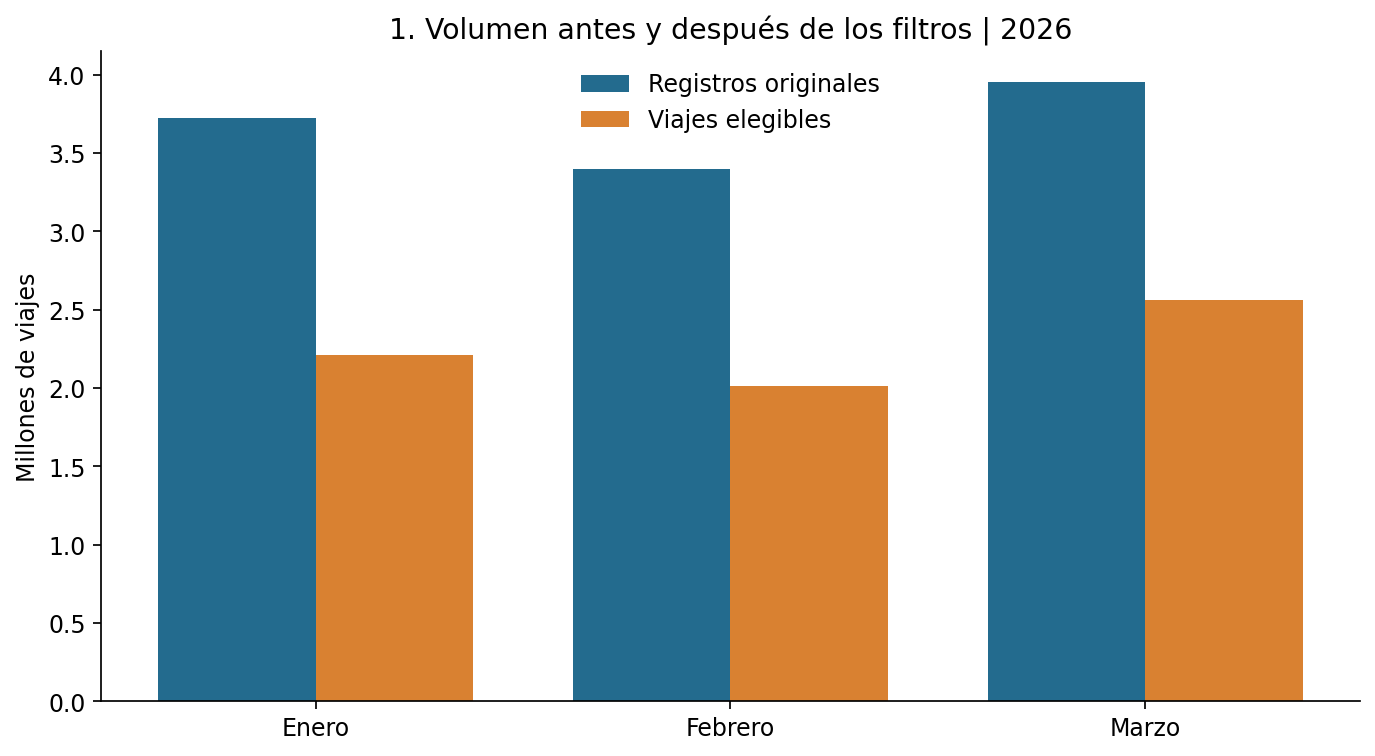

In [8]:
display(Image(filename=str(figures[0])))

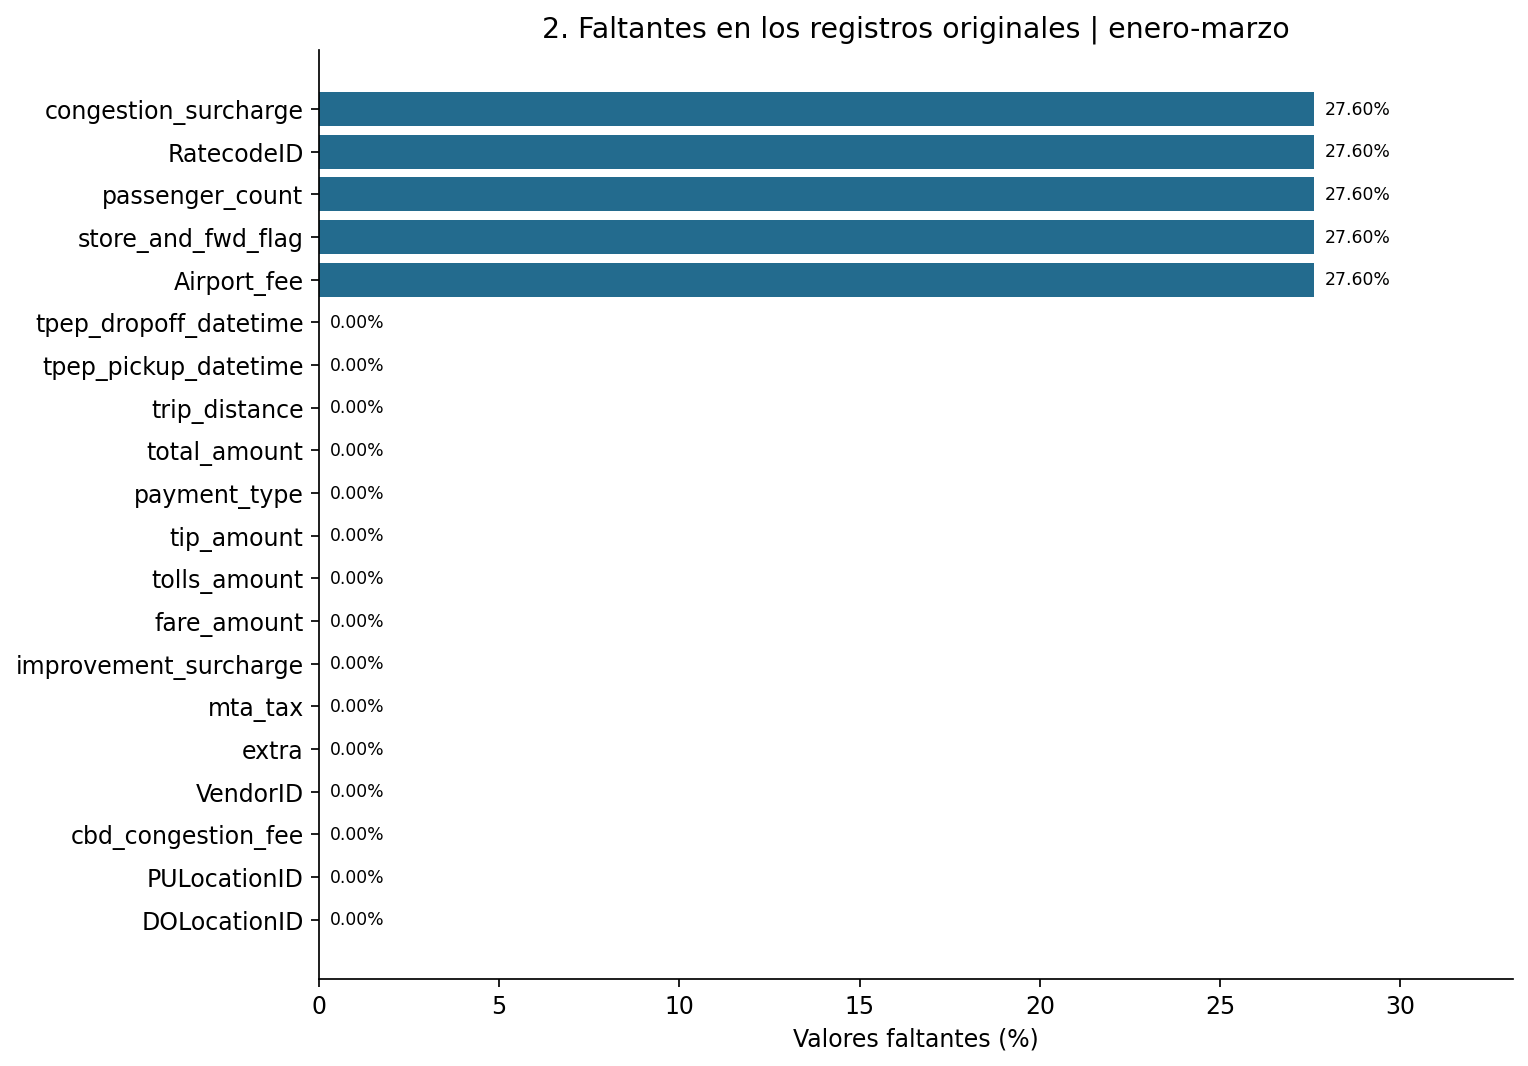

In [9]:
display(Image(filename=str(figures[1])))

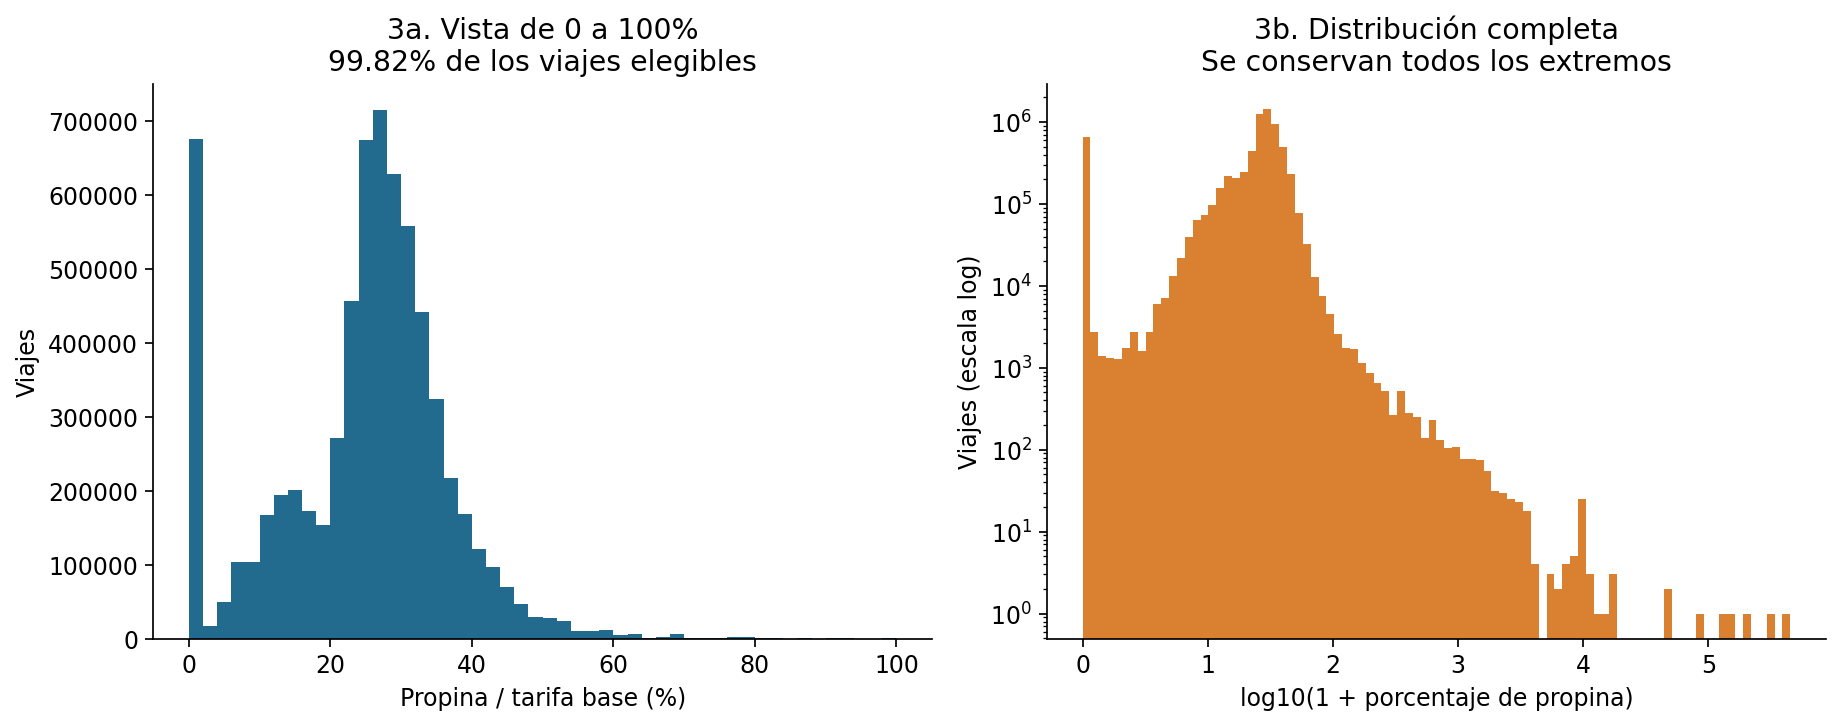

In [10]:
display(Image(filename=str(figures[2])))

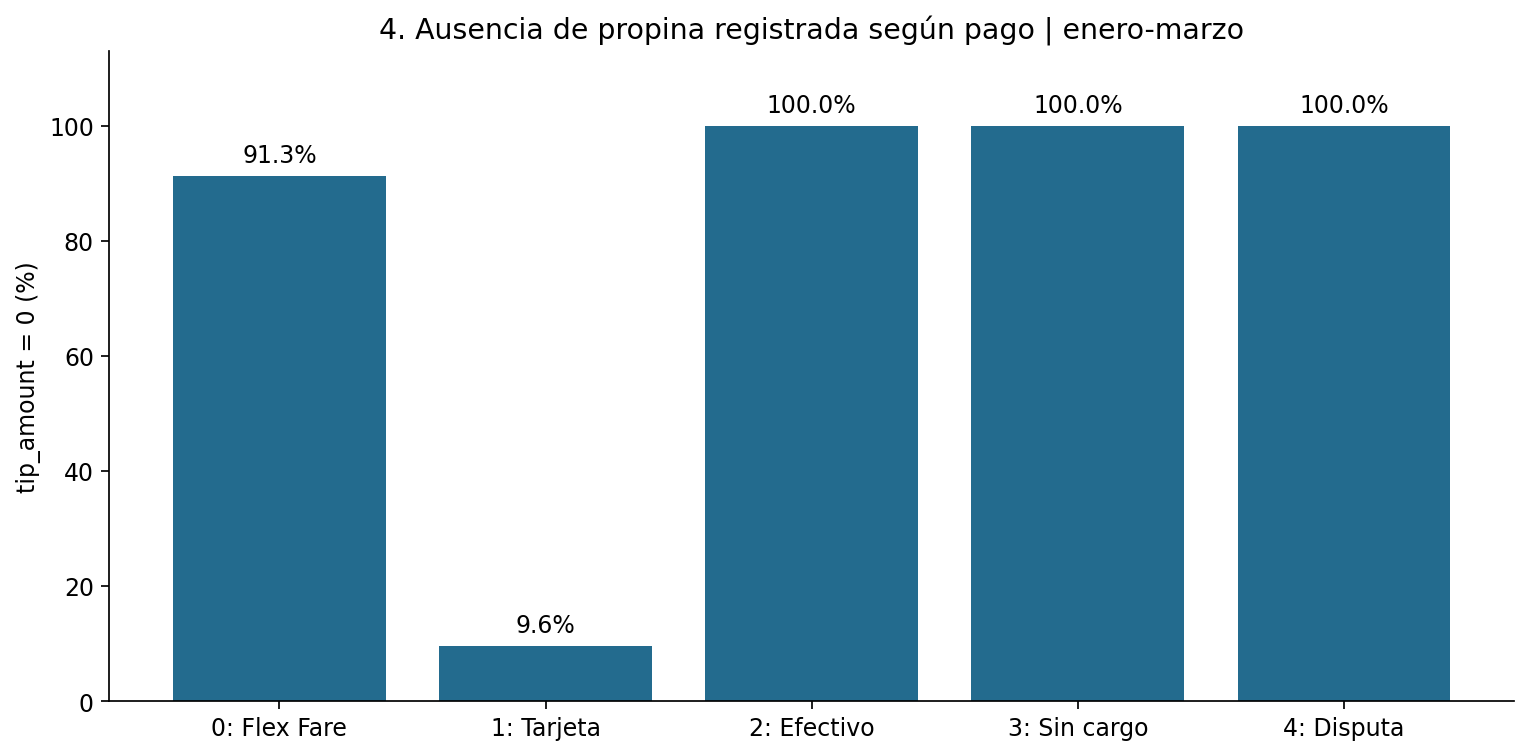

In [11]:
display(Image(filename=str(figures[3])))

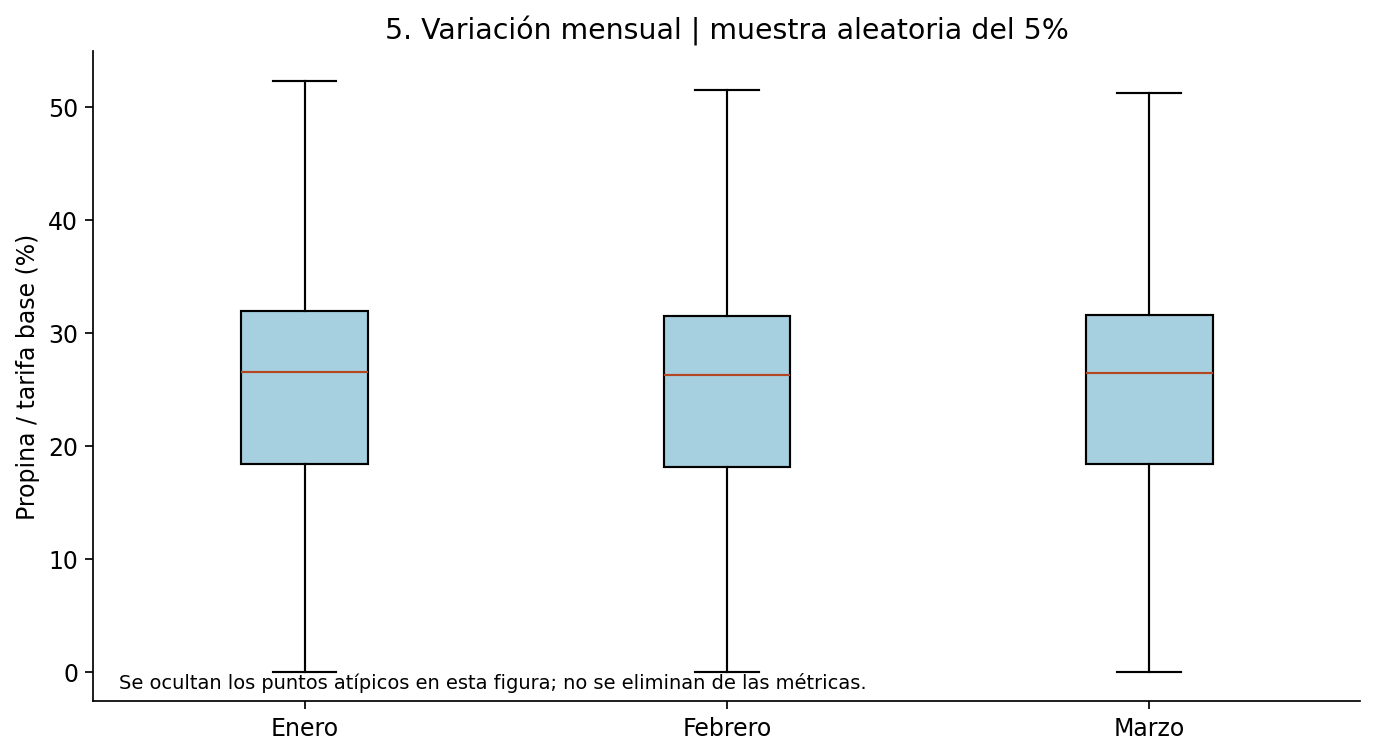

In [12]:
display(Image(filename=str(figures[4])))

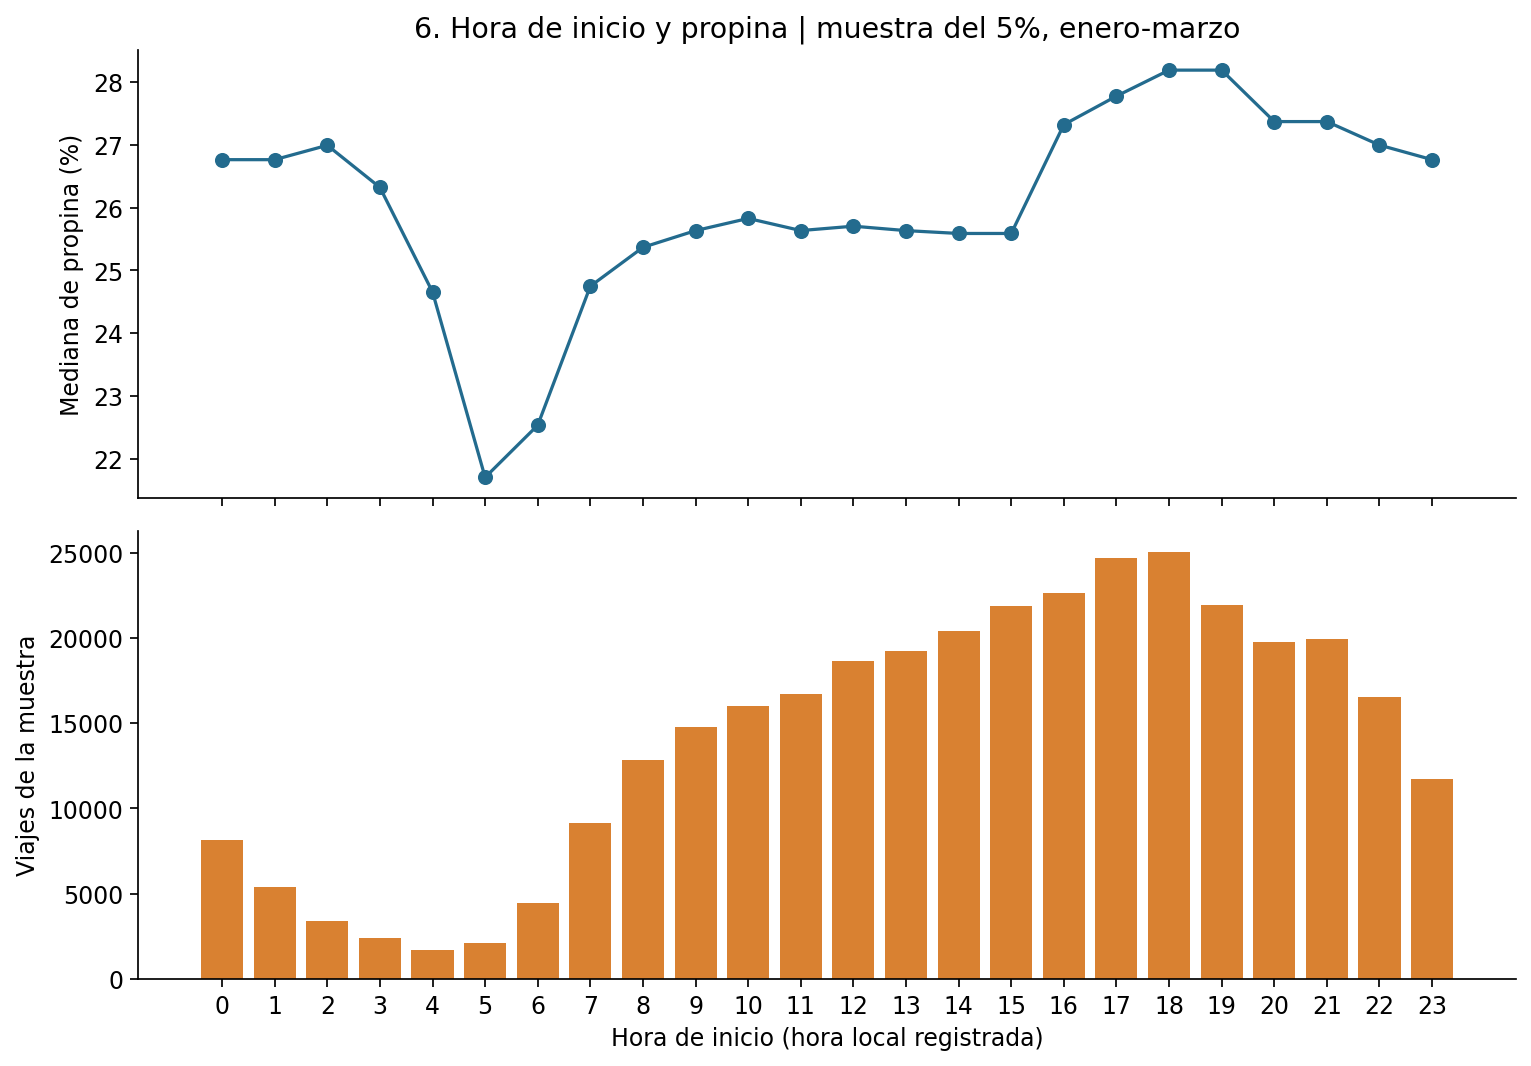

In [13]:
display(Image(filename=str(figures[5])))

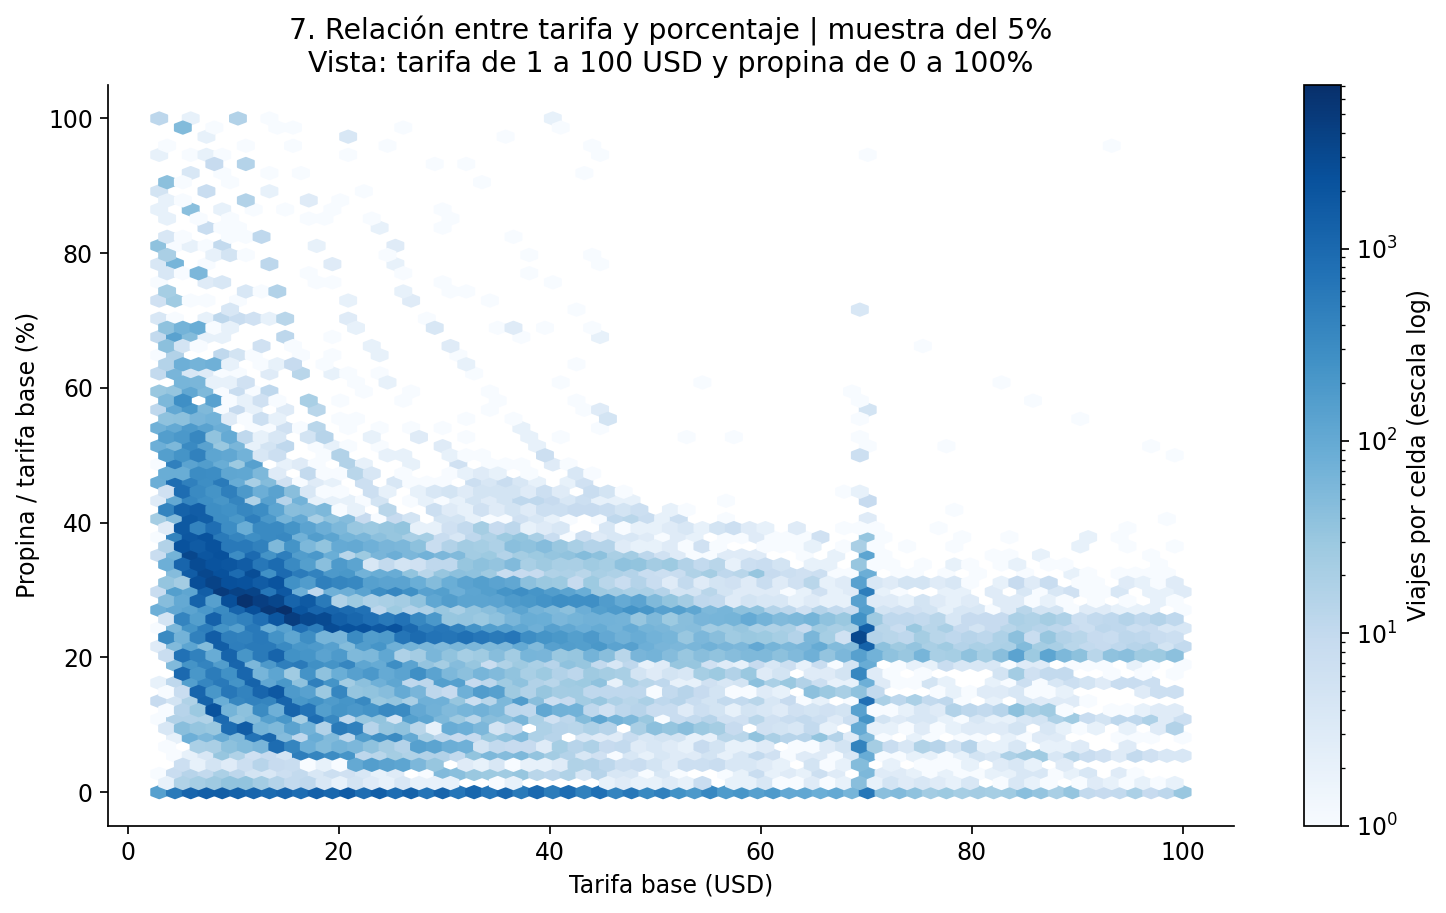

In [14]:
display(Image(filename=str(figures[6])))

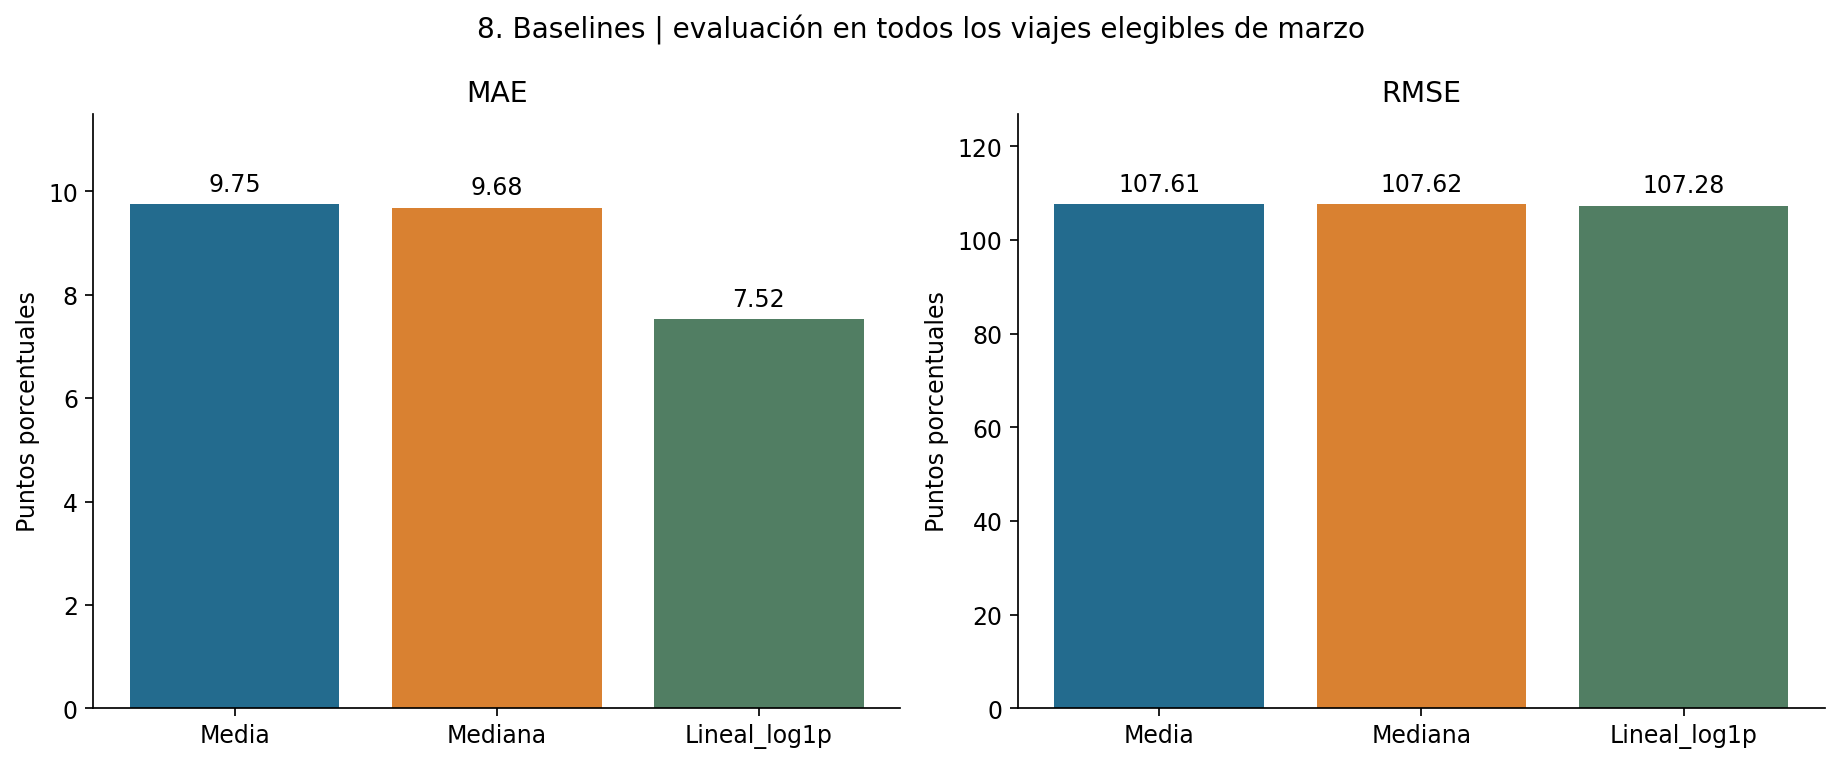

In [15]:
display(Image(filename=str(figures[7])))

## 8. Sensibilidad y límites de interpretación

Se informa también el segmento con tarifa base de al menos USD 1 para ver la influencia de denominadores muy pequeños. Es un diagnóstico adicional definido por una variable disponible, no una sustitución de la población principal. El ajuste de los modelos no cambia para esta comparación.

In [16]:
display(result['sensibilidad'].round(6))
median_row = result['metricas'].set_index('modelo').loc['Mediana']
print(f"La mediana predice {metrics_info['constantes']['Mediana']:.4f}% para todos los viajes.")
print(f"En marzo, su error absoluto medio es {median_row.MAE_pp:.4f} puntos porcentuales.")
print(f"Su RMSE es {median_row.RMSE_pp:.4f}: esta medida amplifica los errores extremos.")
print('Estos son resultados de validación, no la evaluación final de abril.')

La mediana predice 26.3758% para todos los viajes.
En marzo, su error absoluto medio es 9.6848 puntos porcentuales.
Su RMSE es 107.6168: esta medida amplifica los errores extremos.
Estos son resultados de validación, no la evaluación final de abril.


,modelo,segmento,n_evaluacion,MAE_pp,RMSE_pp,R2
0,Media,tarifa_mayor_igual_1_USD,2565390,9.639860,25.326850,-0.000205
1,Mediana,tarifa_mayor_igual_1_USD,2565390,9.576707,25.361905,-0.002975
2,Lineal_log1p,tarifa_mayor_igual_1_USD,2565390,7.415623,24.012249,0.100933


## 9. Sesgos, límites y siguientes pasos

- **Selección por pago:** las conclusiones se refieren a tarjeta. No describen el comportamiento de todos los pasajeros.
- **Propina observada:** incluso en un viaje con tarjeta, puede haber una propina adicional en efectivo que no aparece en el archivo.
- **Temporalidad:** cuatro meses no cubren toda la estacionalidad anual. Marzo orienta el desarrollo; abril se reserva.
- **Variables faltantes:** la calidad depende del proveedor y del tipo de registro. Cero no siempre tiene el mismo significado que ausente.
- **Extremos:** revisar los casos con tarifa pequeña o porcentaje enorme antes de proponer una regla de limpieza nueva. Si se cambia la población, reportar cuántos casos salen y conservar una evaluación comparable.
- **Disponibilidad real:** el dataset contiene viajes cerrados, no eventos de la terminal. El momento de selección de tarjeta antes de introducir propina es un supuesto operativo que no puede comprobarse con estas tablas.
- **Dependencia:** no hay identificador personal ni de conductor para separar usuarios recurrentes. Un split temporal no garantiza independencia total.
- **Ética:** el análisis es descriptivo/predictivo y no justifica rechazar pasajeros ni discriminar zonas según propina esperada. Las correlaciones no explican intenciones ni causas.